# Stage modélisation système Hamiltonien 
## Première approche


On pose $p := (p_x , p_y)$ le momentum à la croisé d'un champ éléctrique et magnétique. La variation du momentum s'écrit: 
$$
\begin{equation}
\frac{dp}{dt} = eE + \frac{e}{c} \left[\frac{\partial \varepsilon (p)}{\partial p}, \ B\right] 
\end{equation}
\tag{1}
$$
Où :
- $e$ est la charge de l'électron
- $E$ est le champ électrique
- $c$ la vitesse de la lumière (prendre 1)
- $\varepsilon(p)$ est la bande de dispersion tel que $\varepsilon(p) = \sqrt{M^2 + v_F^2 p^2}$ (Bande dispersion of massive Dirac fermions)
- $B$ le champ magnétique

Le problème (1) peut se réécrire sous la forme des équations Hamiltonienne suivante:
$$
\begin{equation}
    \begin{cases}
    \dfrac{dp_x}{dt} = \dfrac{\partial \mathcal{H}}{\partial p_y} \\
    \dfrac{dp_y}{dt} = -\dfrac{\partial \mathcal{H}}{\partial p_x}
    \end{cases}
\end{equation}
\tag{2}
$$
Avec $\mathcal{H}(p_x, \ p_y) := \dfrac{eB}{c} \mathcal{W} = \dfrac{eB}{c} \left[\varepsilon(p) + v_d p_y \right] $
et où l'on note $\mathcal{W}$ l'énergie totale et $v_d$ le "drift velocity" de sorte que $v_d = \dfrac{cE}{B}$.

Étudions $\mathscr{H} : t \longmapsto \mathcal{H}(p_x, \ p_y)$
$$ 
\begin{align*}
\dfrac{d\mathscr{H}}{dt} &= \dfrac{\partial \mathcal{H}}{\partial p_x}\dfrac{ dp_x}{dt} + \dfrac{\partial \mathcal{H}}{\partial p_y}\dfrac{ dp_y}{dt} \\
                         &\overset{(2)}{=} \dfrac{\partial \mathcal{H}}{\partial p_x} \dfrac{\partial \mathcal{H}}{\partial p_y} - \dfrac{\partial \mathcal{H}}{\partial p_y} \dfrac{\partial \mathcal{H}}{\partial p_x} \\ 
                         &= 0
\end{align*}
$$

Donc l'Hamiltonien ne vari pas au cours du temps.
Etudions le comportement à l'aide de quelques schémas pour que l'on puisse se faire une idée.

### Schéma Euler Explicite

En partant de (2) on va écrire le schéma explicite:
On calcule $\dfrac{\partial \mathcal{H}}{\partial p_x}$ (resp. $\dfrac{\partial \mathcal{H}}{\partial p_y}$ ) qui vaut $\dfrac{eB v_F^2 p_x}{c\varepsilon(p)}$ (resp. $\dfrac{eB}{c} \left( \dfrac{v_F^2 p_y}{\varepsilon(p)}+ v_d\right)$). 

<!-- Le schéma s'écrit (a corriger j'avais fait une erreur): 
$$ P^{n+1} = \left(1 + \dfrac{\Delta t \ e B \ v_F^2}{c\ \varepsilon(p)} \right) \times P^n$$ -->

Pour simplifier, regardons le cas simple où $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$
Alors $\dfrac{\partial \mathcal{H}}{\partial p_x}$ (resp. $\dfrac{\partial \mathcal{H}}{\partial p_y}$ ) vaut $p_x$ (resp. $p_y$)
Le schéma s'écrit : 
$$
\begin{bmatrix}
p_x^{n+1} \\
p_y^{n+1} \\
\end{bmatrix} 
=
\begin{bmatrix}
1 & \Delta t \\
-\Delta t & 1 \\
\end{bmatrix}
\times 
\begin{bmatrix}
p_x^n \\
p_y^n
\end{bmatrix}
$$

In [2]:
# Packages ------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pyhamsys import HamSys, solve_ivp_sympext, Parameters

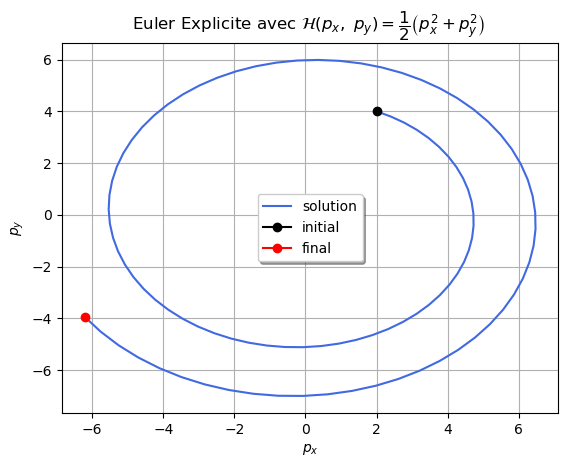

In [20]:
# Euler explicite -----------------------------
def EE_jouet(deltaT, T, P):
    Iteration_matrix = [[1, deltaT], [-deltaT, 1]]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    P = Iteration_matrix @ P
    return np.array(P_trajectory)
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
P_trajectory = EE_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Explicite avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.grid()
plt.show()

### Euler Implicite
De façon similaire on obtient le schéma implicite:
$$
\begin{align*}
\begin{bmatrix}
1 & -\Delta t \\
\Delta t & 1 \\
\end{bmatrix}
\times 
\begin{bmatrix}
p_x^{n+1} \\
p_y^{n+1} \\
\end{bmatrix} 
&=&
\begin{bmatrix}
p_x^n \\
p_y^n
\end{bmatrix} \\
P^{n+1} &=& \dfrac{1}{1 + (\Delta t)^2} 
\begin{bmatrix}
1 & \Delta t \\
-\Delta t & 1 \\
\end{bmatrix}
 \times P^n
\end{align*}
$$

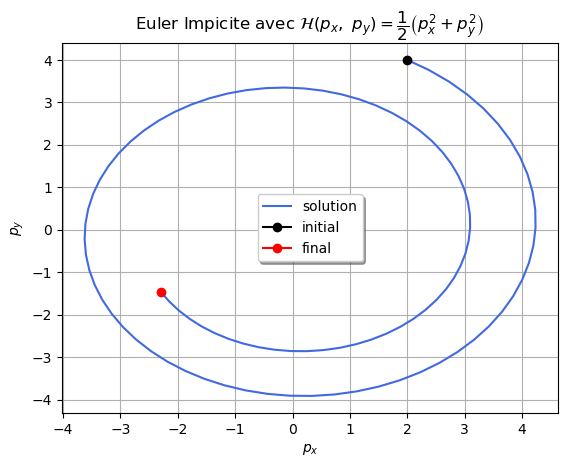

In [19]:
# Euler implicite -----------------------------
def EI_jouet(deltaT, T, P):
    Iteration_matrix = [[1/(1 + deltaT**2), deltaT/(1 + deltaT**2)], [-deltaT/(1 + deltaT**2), 1/(1 + deltaT**2)]]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    P = Iteration_matrix @ P
    return np.array(P_trajectory)
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
P_trajectory = EI_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Impicite avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.grid()
plt.show()

### Euler Symplectique
On code le schéma suivant:
$$
\begin{cases}
\begin{align*}
x_{n+1} &=& x_n + h \partial_x \mathcal{H}(x_n, y_{n+1}) \\
y_{n+1} &=& y_n + h \partial_y \mathcal{H}(x_n, y_{n+1}) 
\end{align*}
\end{cases}
$$
On repart de notre problème $\mathcal{H}(p_x^n, \ p_y^{n+1}) = \dfrac{1}{2}\left((p_x^{n})^2 + (p_y^{n+1})^2\right)$ avec $\partial_x \mathcal{H} = p_x^n$ et $  \partial_y \mathcal{H} = p_y^{n+1}$. \\
Puisque notre problème vérifie:
$$
\begin{cases}
\begin{align*}
\partial_t p_x &=& \partial_y H \\
\partial_t p_y &=& -\partial_x H
\end{align*}
\end{cases}
$$
On obtient:
$$
\begin{cases}
\begin{align*}
p_x^{n+1} &=p_x^n + \Delta t \times p_y^{n+1} \\ 
p_y^{n+1} &= p_y^n - \Delta t \times p_x^n
\end{align*}
\end{cases} \\
$$
Ce qui se réécrit:
$$
 \begin{bmatrix} 1 & - \Delta t \\ 0 & 1 \end{bmatrix} P^{n+1} = \begin{bmatrix} 1 & 0 \\ - \Delta t & 1 \end{bmatrix} P^n$$
Donc le schéma final est:
$$
P^{n+1} = \begin{bmatrix} 1 -(\Delta t)^2 & \Delta t \\ -\Delta t & 1 \end{bmatrix} \times P^n
$$



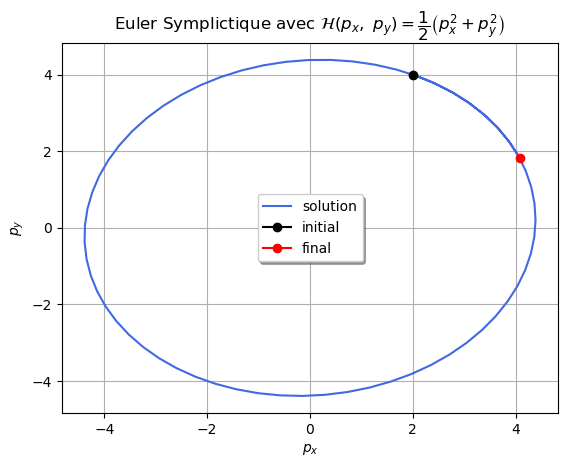

In [17]:
# Euler Symplictique -----------------------------
def ES_jouet(deltaT, T, P):
    Iteration_matrix = [[1 - deltaT**2, deltaT], [-deltaT, 1]]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    P = Iteration_matrix @ P
    return np.array(P_trajectory)
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 7
P_trajectory = ES_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Symplictique avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.grid()
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.show()

### Comparaison des 3 méthodes



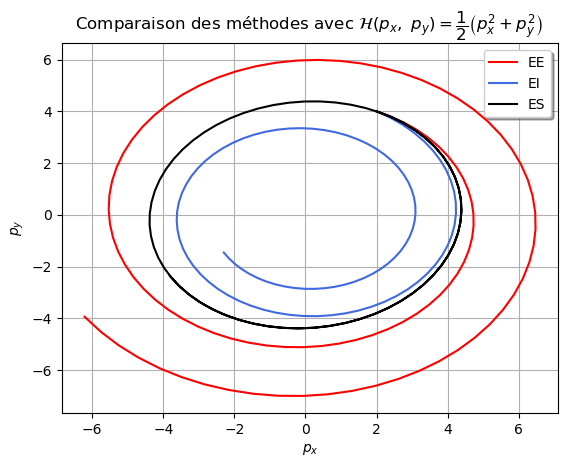

In [15]:
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
#---- Trajectoires selon les méthodes
traj_EX = EE_jouet(deltaT, T, P)
plt.plot(traj_EX[:, 0], traj_EX[:,1], color='red',label='EE')

traj_EI = EI_jouet(deltaT, T, P)
plt.plot(traj_EI[:, 0], traj_EI[:,1], color='royalblue',label='EI')

traj_ES = ES_jouet(deltaT, T, P)
plt.plot(traj_ES[:, 0], traj_ES[:,1], color='black',label='ES')

plt.legend(shadow=True)
plt.grid()
plt.title(r'Comparaison des méthodes avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.show()

## Cas concret avec l'expérience

Dans cette partie on reprends le bon Hamiltonien, c'est à dire : 
$$
\begin{align*}
\dfrac{\partial \mathcal{H}}{\partial p_x} &=& \dfrac{eB v_F^2 p_x}{c\varepsilon(p)} \\
\dfrac{\partial \mathcal{H}}{\partial p_y} &=& \dfrac{eB}{c}\left( \dfrac{v_F^2 p_y}{\varepsilon(p)}+ v_d\right)
\end{align*}
$$

Posons $G:=\dfrac{\Delta t eB \ v_F^2}{c \ \varepsilon(p)}$, alors comme dans le cas jouet on peut réécrire le schéma symplectique :
$$
P^{n+1} = \begin{bmatrix} 1 -G^2 & G \\ -G & 1 \end{bmatrix} \times P^n + \begin{bmatrix} \dfrac{\Delta t \ eB}{c} v_d \\ 0 \end{bmatrix}
$$


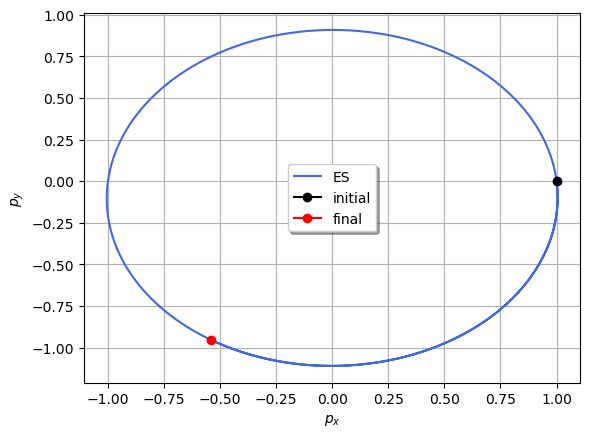

In [22]:
# Euler Symplictique Définition -----------------------------
""" Ce schéma n'est correct que pour l'Hamiltonien défini par le papier de Sergey Krishtopenko. """
def varepsilon(p):
    M = 13/1000 #valeur au hasard
    vF = 1 #pareil
    px = p[0]
    py = p[1]
    return np.sqrt(M**2 + vF**2 * (px**2 + py**2))

def ES(deltaT, T, P, e, B, Vf, c, varepsi, vd):
    '''
    deltaT = Pas de temps
    T : temps final
    e : charge de l'électron
    B : champs magnétique       # prendre .7
    Vf : vitesse de fermi
    c : vitesse de la lumière
    varepsi : fonction bande qui dépend de P
    vd: vitesse drift (E/B)
    '''

    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
            
        G = (deltaT * e * B * Vf**2) / (c * varepsi(P))
        Iteration_matrix = [[1 - G**2, G], [-G, 1]]
        Drift_matrix = [deltaT * e * B * vd /c, 0]    
        P = Iteration_matrix @ P + Drift_matrix
        t += deltaT
        P_trajectory.append(P)

    deltaT = T - t
    G = (deltaT * e * B * Vf**2) / (c * varepsi(P))
    Iteration_matrix = [[1 - G**2, G], [-G, 1]]
    P = Iteration_matrix @ P + Drift_matrix
    P_trajectory.append(P)
    return np.array(P_trajectory)
# test ---choix des valeurs au hasard-----------------------------------------------------
T = 4* np.pi
P = np.array([1, 0])
e = 1
B = 0.7
Vf = 1
c = 1
vd = 0.1#5
deltaT = 0.01

# ----------------------------------------------
traj_ES = ES(deltaT, T, P, e, B, Vf, c, varepsilon, vd)
plt.plot(traj_ES[:, 0], traj_ES[:,1], color='royalblue',label='ES')
plt.plot(traj_ES[0,0], traj_ES[0, 1], color='black', marker='o', label='initial')
plt.plot(traj_ES[-1,0], traj_ES[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.grid()
plt.show()



### Bande Fermions de Dirac et Graphène $G0$
On compare le résultat précédent avec les résultats obtenus avec des méthodes de la libraire PyHamSys.
Puis on ajoute un méthode pour faire la même chose avec une bande de graphène G0 (identique à ce qu'on utilise pour le code "streaming example")

        Computation finished in 0 seconds


Choix système : p_system


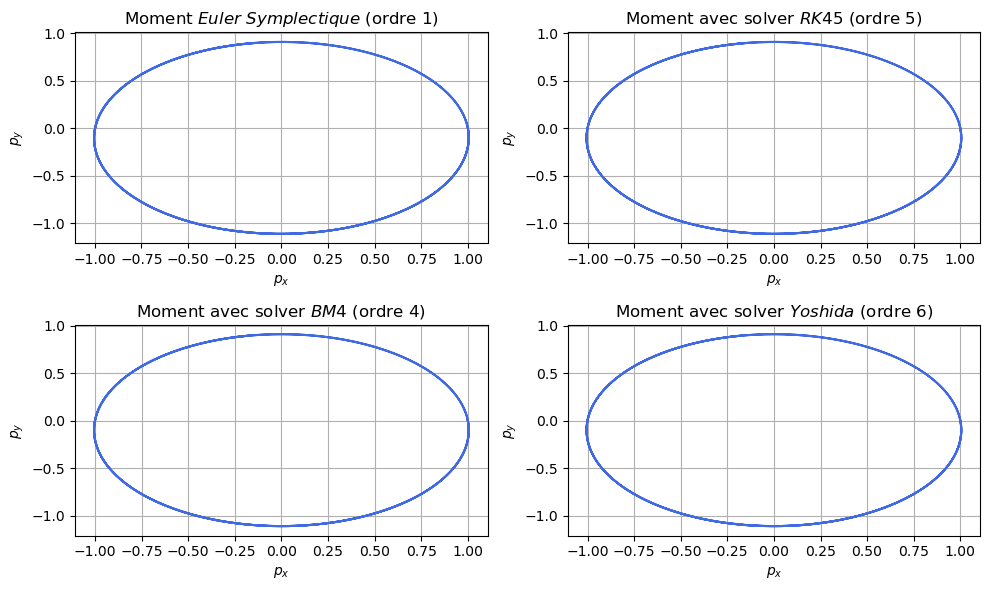

        Computation finished in 0 seconds


Choix système : y_dot_G0


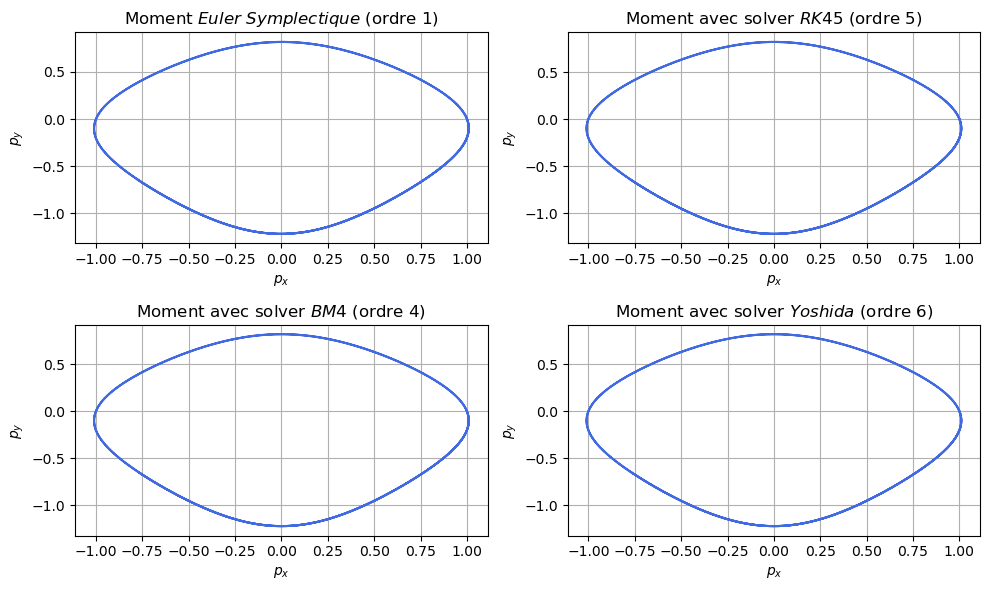

In [ ]:
# Code avec PyHamSys ------------------------
# (Cette cellule utilise du code de la cellule précédente)

# Hamiltonien Défintion
hs = HamSys(ndof=1)

deltaT = 0.01
T = 4 * 2 * np.pi 
time_range = np.arange(0, T + deltaT , deltaT) #On dépasse un peu le temps final.
P = np.array([1, 0])
e = 1
B = 0.7
vF = 1
c = 1
vd = 0.1 #5.0

def p_system(t, P): #resolution papier
    G1 = ( e * B * Vf**2) / (c * varepsilon(P)) 
    G2 = (e * B / c)
    q, p = np.split(P, 2)
    y0 = G2 * ((Vf**2 * p / varepsilon(P)) + vd) 
    y1 = -G1 * q

    return np.concatenate((y0, y1), axis=None)

def y_dot_G0(t, y):   # for graphene (benoit)
    q, p = y[0], y[1]
    y0 =    p * (1+q*q)/2+ vd
    y1 =   -q*  (1+p*p)/2
    return np.array([y0, y1])

# ES_graphene ---------------------------------------------------------
def ES_graphene(deltaT, T, P, vd):
    '''
    deltaT = Pas de temps
    vd: vitesse drift (e/B)
    '''
    P_trajectory = [P]
    t = 0
    lmbda = deltaT / 2

    while ( t + deltaT < T):
        A, B = P[0], P[1]
        Y = B - lmbda * (A + A * B**2)
        discriminant = 1 - 4 * lmbda * Y * ( lmbda * Y + A + deltaT * vd)
        X1 = (1 + np.sqrt(discriminant)) / (2 * lmbda * Y)
        X2 = (1 - np.sqrt(discriminant)) / (2 * lmbda * Y)

        '''
        Pour le choix de X j'ai d'abord choisi de prendre le plus petit de façon arbitraire.
        Ensuite j'ai voulu regarder laquelle des deux valeurs est la plus proche de l'anciene et en comparant avec l'ancienne méthode on retrouve le même résultat.
        On trouve un résulat proche des solveurs de PyHamsys donc pour l'instant je vais garder.
        '''

        X = X1 if abs(X1 - A) < abs(X2 - A) else X2
        P = [X, Y]
        # P_test = [X2, Y]
        t += deltaT
        P_trajectory.append(P)

    # print(f'C\'est tout le temps X2 qu\'on prend ? Réponse : {P_test == P} ')
    deltaT = T - t
    A, B = P[0], P[1]
    Y = B - lmbda * (A + A * B**2)
    discriminant = 1 - 4 * lmbda * Y * ( lmbda * Y + A + deltaT * vd)
    X1 = (1 + np.sqrt(discriminant)) / (2 * lmbda * Y)
    X2 = (1 - np.sqrt(discriminant)) / (2 * lmbda * Y)
    X = X1 if abs(X1 - A) < abs(X2 - A) else X2
    P = [X, Y]
    P_trajectory.append(P)
    return np.array(P_trajectory)

# resolution ---------------------------------------------------------


system_liste = [p_system, y_dot_G0]
for i, name in enumerate(system_liste):
    hs.y_dot = name # choix du système
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='BM4'))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet'))
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Yos6'))
    if i == 0:
        Moment_ES = ES(deltaT, T, P, e, B, Vf, c, varepsilon, vd)
    else :
        Moment_ES_graphene = ES_graphene(deltaT, T, P, vd)
    
    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
    # Plot ------------------------------------------
    print(f'Choix système : {name.__name__}')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,6))
    if i == 0:
        ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
        ax1.set_xlabel(r'$p_x$')
        ax1.set_ylabel(r'$p_y$')
        ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')
    else :
        ax1.plot(Moment_ES_graphene[:, 0], Moment_ES_graphene[:,1] ,color='royalblue',label='ES')
        # ax1.plot(Moment_ES_graphene[-1, 0], Moment_ES_graphene[-1, 1], marker='o', color='red',label='Dernier')
        # ax1.plot(Moment_ES_graphene[-2, 0], Moment_ES_graphene[-2,1], marker='o', color='black',label='Avant-Dernier')
        ax1.set_xlabel(r'$p_x$')
        ax1.set_ylabel(r'$p_y$')
        ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')        

    ax2.plot(sol_RK45.y[0], sol_RK45.y[1], color='royalblue')
    ax2.set_xlabel(r'$p_x$')
    ax2.set_ylabel(r'$p_y$')
    ax2.set_title(r'Moment avec solver $RK45$ (ordre 5)')

    ax3.plot(sol_BM4.y[0], sol_BM4.y[1], color='royalblue')
    ax3.set_xlabel(r'$p_x$')
    ax3.set_ylabel(r'$p_y$')
    ax3.set_title(r'Moment avec solver $BM4$ (ordre 4)')
    

    ax4.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
    ax4.set_xlabel(r'$p_x$')
    ax4.set_ylabel(r'$p_y$')
    ax4.set_title(r'Moment avec solver $Yoshida$ (ordre 6)')
    ax1.grid(), ax2.grid(), ax3.grid(), ax4.grid()
    plt.tight_layout()
    plt.show()

# print(f'Avant dernier point ES_graphène : [{np.round(Moment_ES_graphene[-2, 0], 3)},  {np.round(Moment_ES_graphene[-2,1],3)}] ')
# print(f'Avant Dernier point RK45 : [ {np.round(sol_RK45.y[0][-2],3)}, {np.round(sol_RK45.y[1][-2],3)} ] ')
# print(f'Avant Dernier point BM4 : [ {np.round(sol_BM4.y[0][-2],3)}, {np.round(sol_BM4.y[1][-2], 3)} ] ')
# print(f'Avant Dernier point Yoshida: [ {np.round(sol_Yoshida.y[0][-2],3)}, {np.round(sol_Yoshida.y[1][-2], 3)} ] ')

# print(f'Dernier point ES_graphène : [{np.round(Moment_ES_graphene[-1, 0], 3)},  {np.round(Moment_ES_graphene[-1,1],3)}] ')
# print(f'Dernier point RK45 : [ {np.round(sol_RK45.y[0][-1],3)}, {np.round(sol_RK45.y[1][-1],3)} ] ')
# print(f'Dernier point BM4 : [ {np.round(sol_BM4.y[0][-1],3)}, {np.round(sol_BM4.y[1][-1],3)} ] ')
# print(f'Dernier point Yoshida: [ {np.round(sol_Yoshida.y[0][-1],3)}, {np.round(sol_Yoshida.y[1][-1], 3)} ] ')


### Bande parabolique

Dans cette partie on test rapidement le schéma pour une bande de dispersion parabolique $\varepsilon(p) = \dfrac {\alpha p^2}{2}$.
Oon devrait alors retrouver des trajectoires sphériques dans l'espace des moments.
Après quelques tests en fonction de alpha j'ai pu trouver différentes formes géométriques. Il suffit d'ajuster le pas de temps pour retrouver des cercles.
Voilà quelques exemples:

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  1 


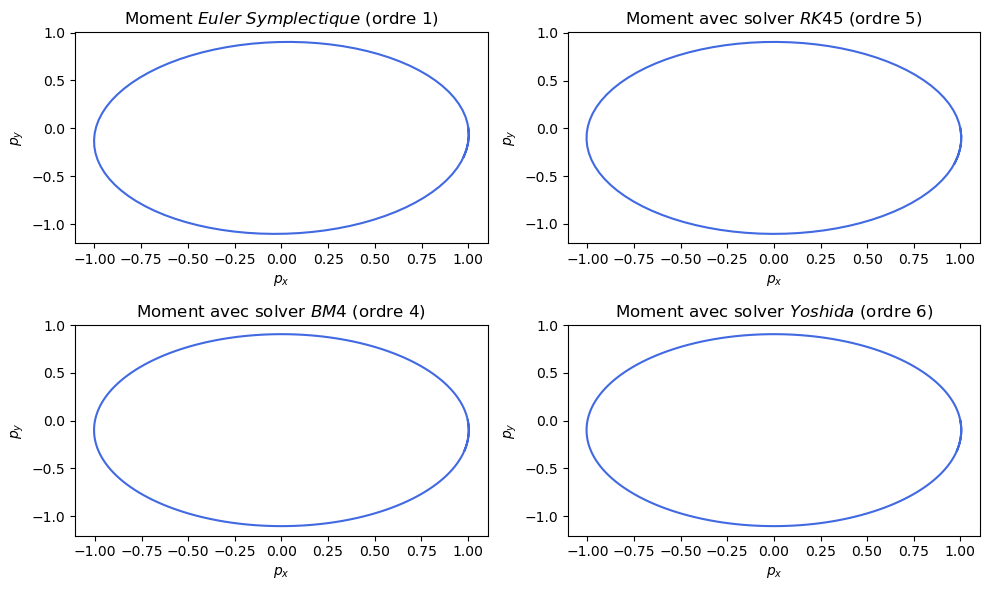

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  5 


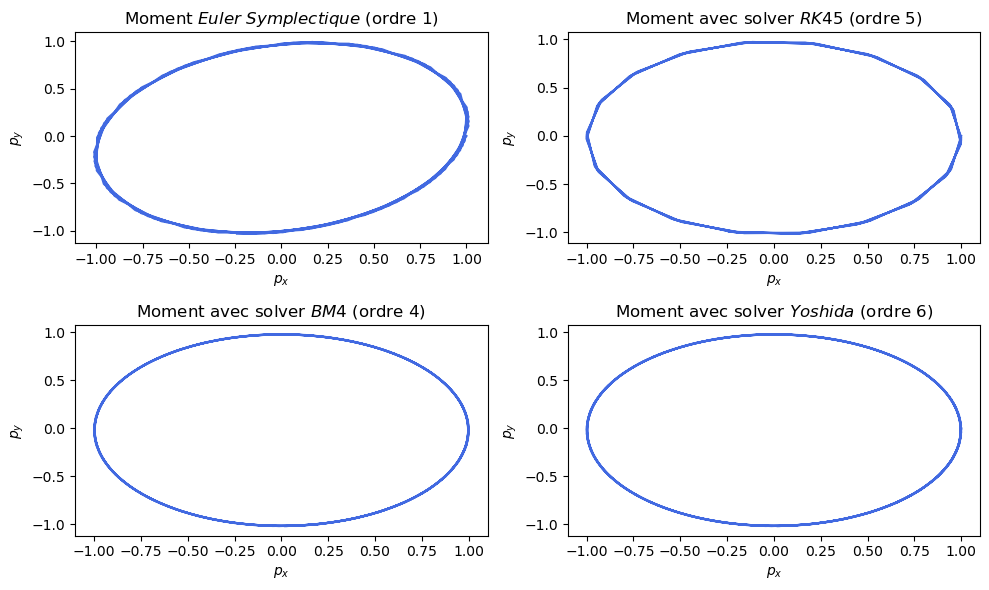

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  10 


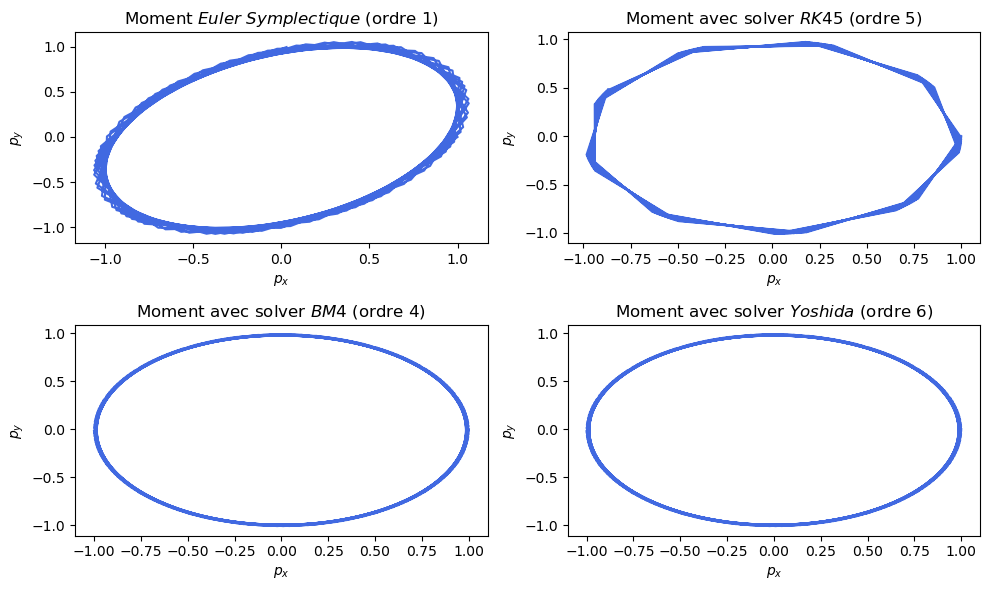

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  20 


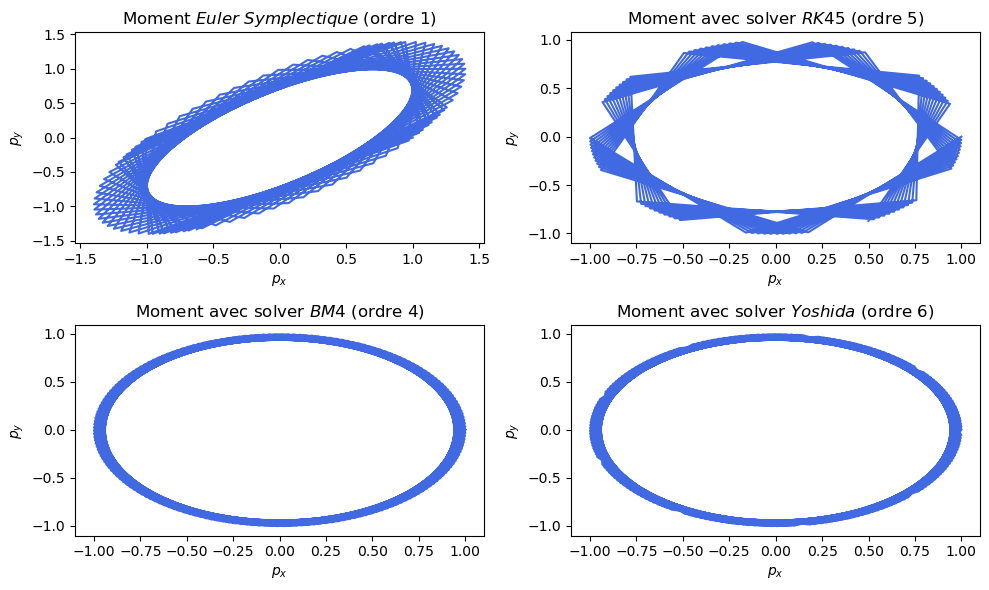

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  25 


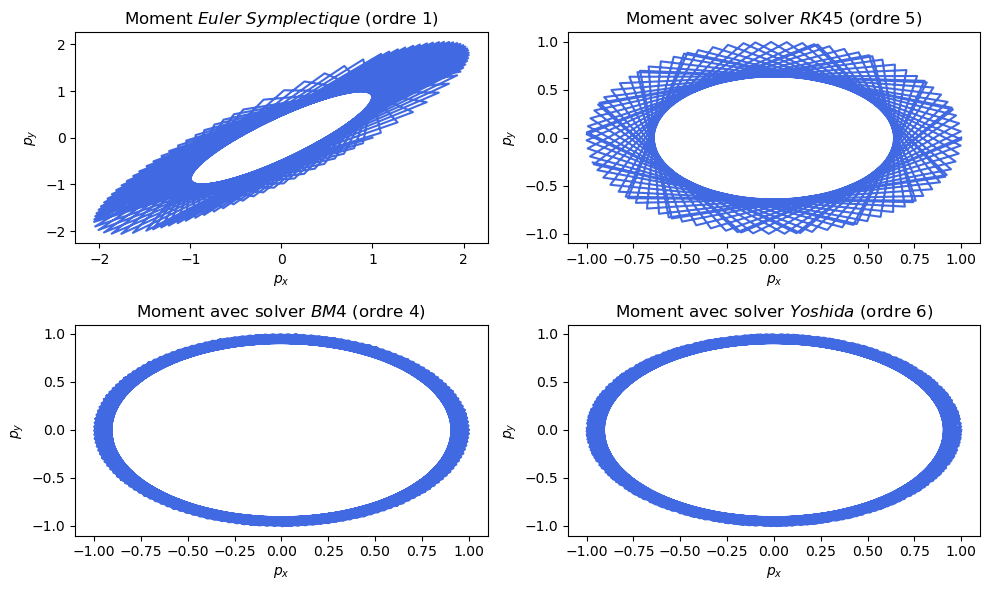

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  30 


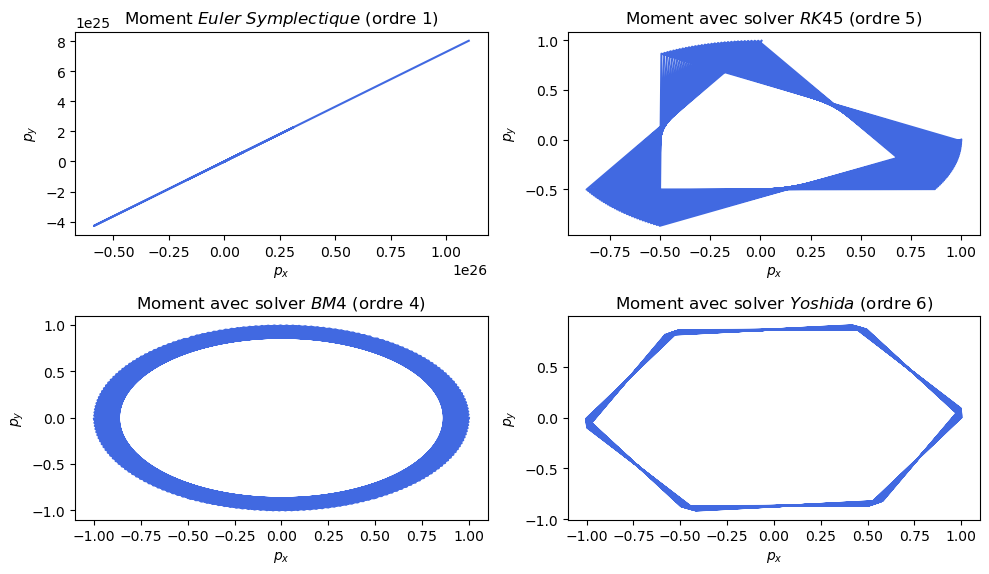

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  40 


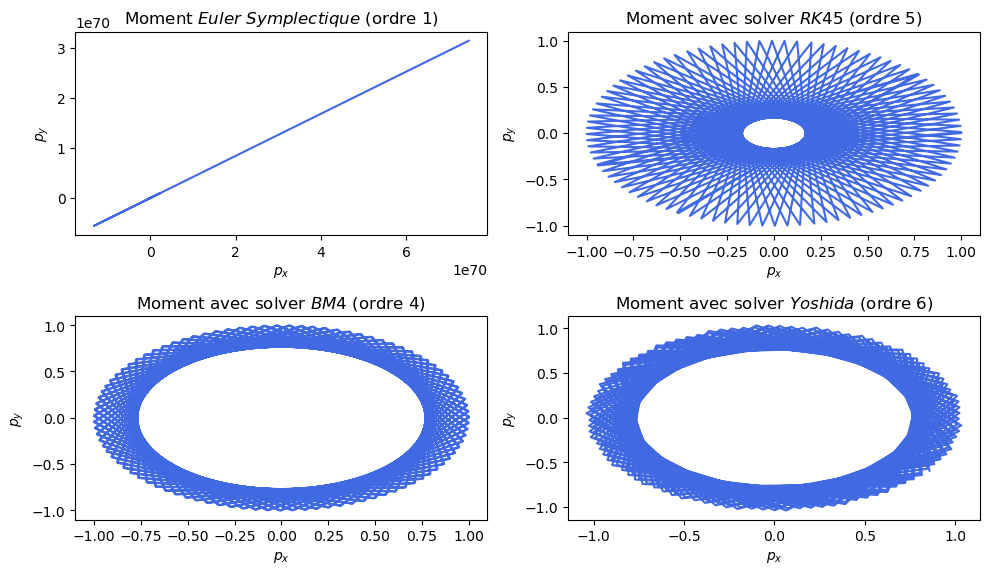

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  50 


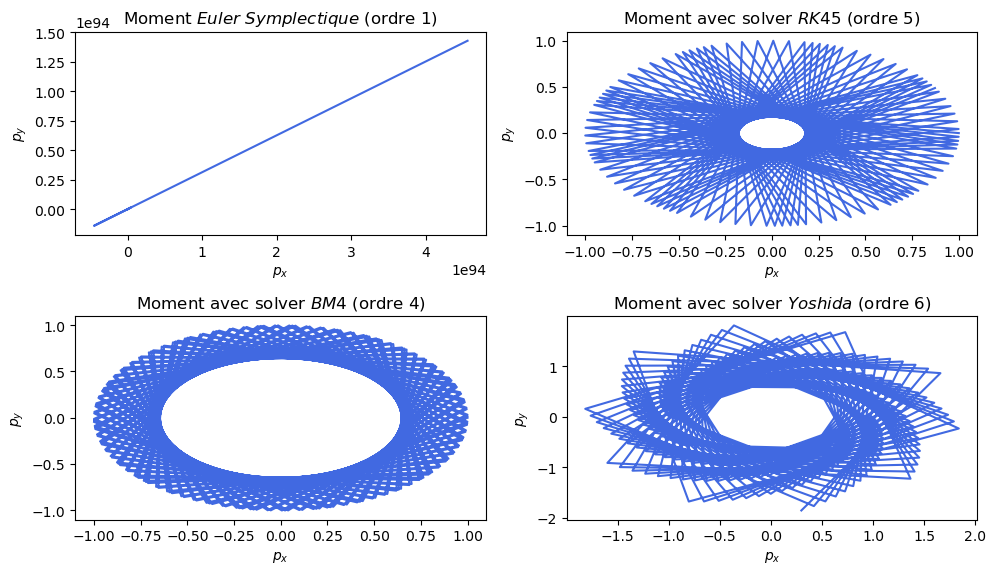

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  60 


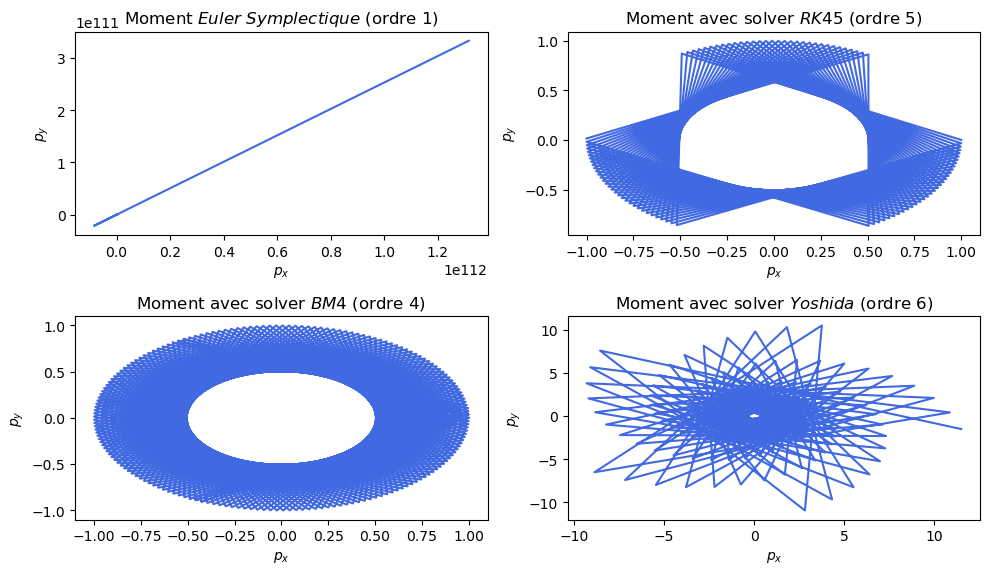

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  75 


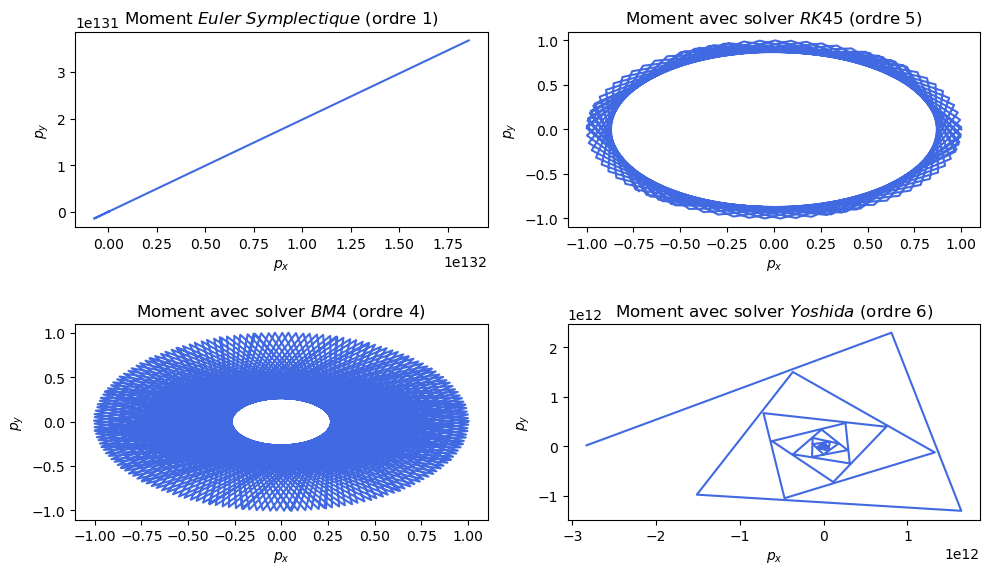

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  80 


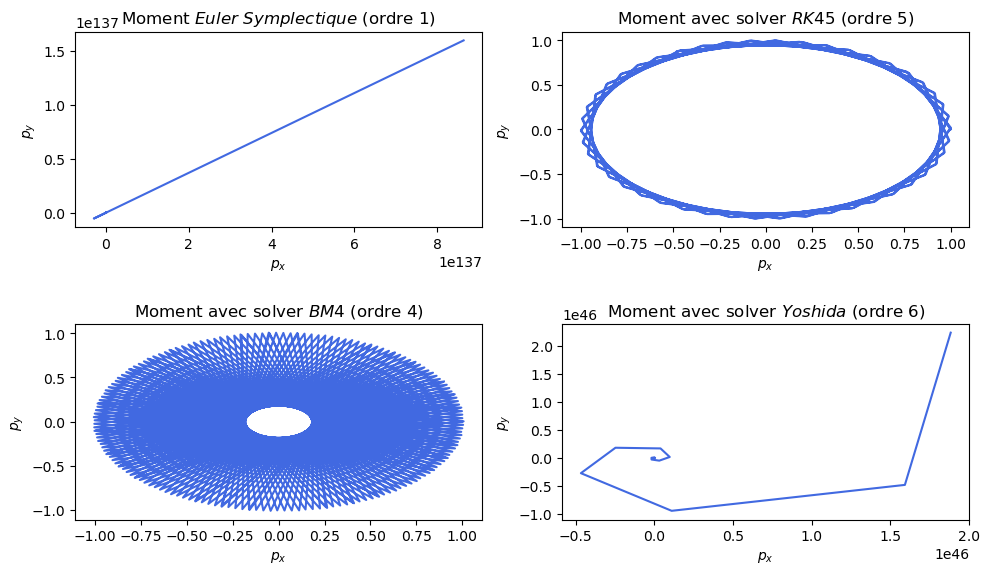

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  90 


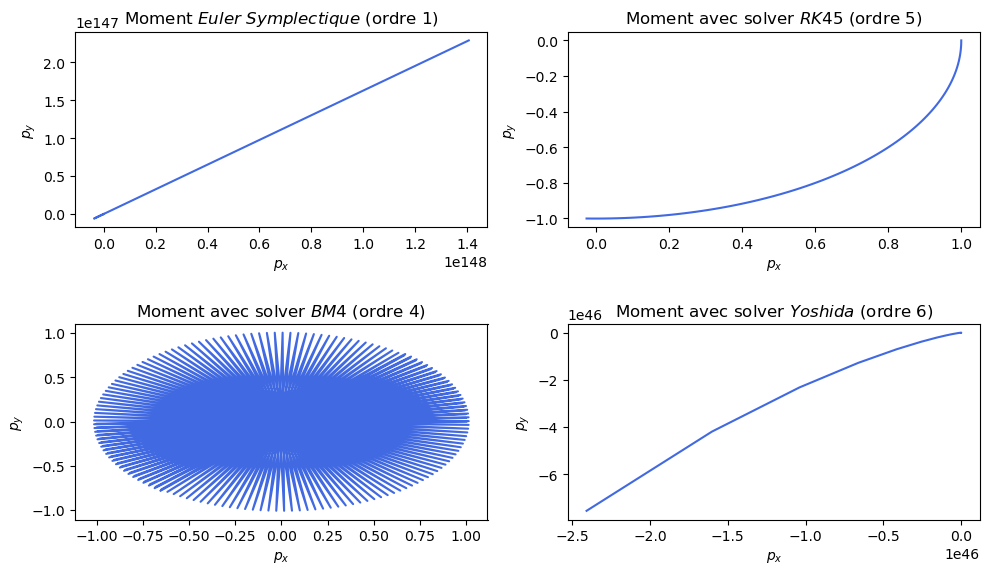

In [33]:
deltaT = 0.1 # pour 0.01 ça marche mieux. Etudier le pas de temps pour trouver ce qui est le mieux.
T = 3* np.pi
time_range = np.arange(0, T + deltaT , deltaT) #On dépasse un peu le temps final.
P = np.array([1, 0])
e = 1
B = 0.7
vF = 1
c = 1
vd = 0.1 #5.0
alpha_liste = [ 1, 5, 10,20, 25, 30, 40, 50, 60, 75, 80, 90]

# def varepsilon_parabolique(p, alpha):
#     px = p[0]
#     py = p[1]
    
#     return  alpha * (px**2 + py**2) / 2

def ES_parabolique(deltaT, T, P, e , B, c, alpha):
    G = deltaT * e * B * alpha / c
    Iteration_matrix = [[1 - G**2, G], [-G, 1]]
    Drift_matrix = [deltaT * e * B * vd /c, 0]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P + Drift_matrix
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    Drift_matrix = [deltaT * e * B * vd /c, 0] 
    P = Iteration_matrix @ P + Drift_matrix
    return np.array(P_trajectory)
   
def p_system(t, P): #resolution papier pour bande parabolique
    G =  e * B  / c
    return np.array( [G * (alpha * P[1] + vd)  , -G * alpha * P[0] ])
#---------------------------------------------------------------------------------------------------
for i, alpha in enumerate(alpha_liste):
    hs.y_dot = p_system # choix du système
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='BM4'))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet'))
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Yos6'))

    Moment_ES = ES_parabolique(deltaT, T, P, e, B, c, alpha)

    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
# Plot ------------------------------------------

    print(f'Comparaison des méthodes avec alpha =  {alpha} ')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,6))

    ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
    ax1.set_xlabel(r'$p_x$')
    ax1.set_ylabel(r'$p_y$')
    ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')  

    # ax1.plot(sol_Verlet.y[0], sol_Verlet.y[1], color='royalblue',label='ES')
    # ax1.set_xlabel(r'$p_x$')
    # ax1.set_ylabel(r'$p_y$')
    # ax1.set_title(r'Moment solver $Verlet$ (ordre 2)') 


    ax2.plot(sol_RK45.y[0], sol_RK45.y[1], color='royalblue')
    ax2.set_xlabel(r'$p_x$')
    ax2.set_ylabel(r'$p_y$')
    ax2.set_title(r'Moment avec solver $RK45$ (ordre 5)')

    ax3.plot(sol_BM4.y[0], sol_BM4.y[1], color='royalblue')
    ax3.set_xlabel(r'$p_x$')
    ax3.set_ylabel(r'$p_y$')
    ax3.set_title(r'Moment avec solver $BM4$ (ordre 4)')

    ax4.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
    ax4.set_xlabel(r'$p_x$')
    ax4.set_ylabel(r'$p_y$')
    ax4.set_title(r'Moment avec solver $Yoshida$ (ordre 6)')

    plt.tight_layout()
    plt.show()

### Graphène (Papier Sergei)

Si on utilise du graphène, la bande de dispersion s'écrit alors $\varepsilon(p) = v_F p$.
Regardons à nouveaux les moments obtenus avec une bande de cette forme

        Computation finished in 0 seconds


Comparaison des méthodes avec vF =  0.8 


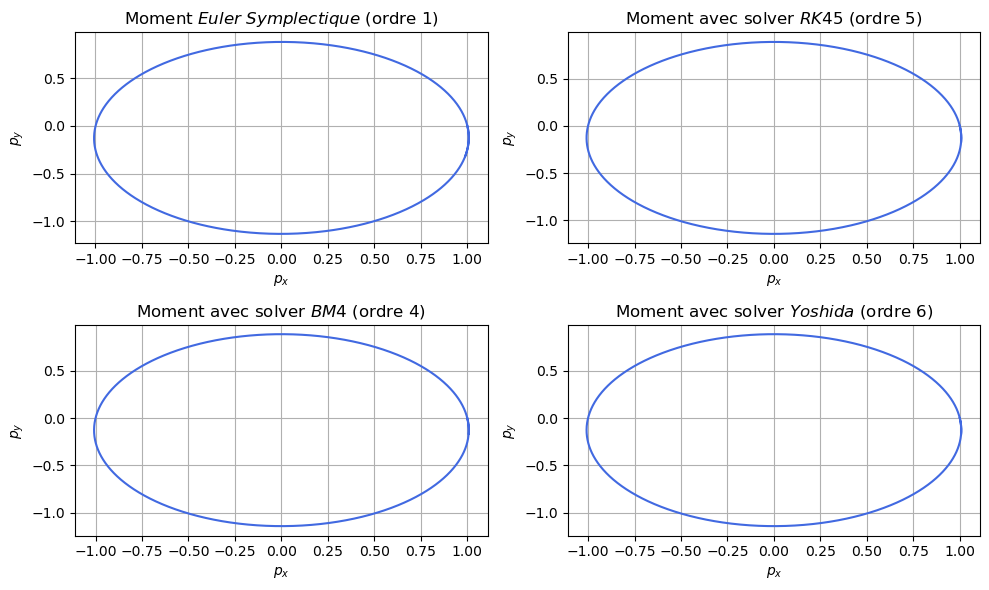

In [38]:
deltaT = 0.01
T = 15/4* np.pi
time_range = np.arange(0, T + deltaT , deltaT) #On dépasse un peu le temps final.
P = np.array([1, 0])
e = 1
B = 0.7
vF = 1
c = 1
vd = 0.1 #5.0
vF_liste = [0.8]

def varepsilon_graphene(p):
    px = p[0]
    py = p[1]
    return  vF * np.sqrt((px**2 + py**2)) 

def ES_graphene(deltaT, T, P, e , B, c, vF):
    G = deltaT * e * B * vF**2 / (c * varepsilon_graphene(P))
    Iteration_matrix = [[1 - G**2, G], [-G, 1]]
    Drift_matrix = [deltaT * e * B * vd /c, 0]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P + Drift_matrix
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    Drift_matrix = [deltaT * e * B * vd /c, 0]
    P = Iteration_matrix @ P + Drift_matrix
    return np.array(P_trajectory)
   
def p_system(t, P): #resolution papier pour bande linéaire
 G =  e * B  / c
 q, p = np.split(P, 2)
 y0 = G * ((vF**2 * p / varepsilon_graphene(P)) + vd)
 y1 = -G * (vF**2 * q / varepsilon_graphene(P))
 return np.concatenate((y0 , y1), axis=None)
#---------------------------------------------------------------------------------------------------
for i, vF in enumerate(vF_liste):
    hs.y_dot = p_system # choix du système
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='BM4'))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet'))
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Yos6'))

    Moment_ES = ES_graphene(deltaT, T, P, e, B, c, vF)

    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
# Plot ------------------------------------------

    print(f'Comparaison des méthodes avec vF =  {vF} ')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,6))

    ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
    ax1.set_xlabel(r'$p_x$')
    ax1.set_ylabel(r'$p_y$')
    ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')  

    # ax1.plot(sol_Verlet.y[0], sol_Verlet.y[1], color='royalblue',label='ES')
    # ax1.set_xlabel(r'$p_x$')
    # ax1.set_ylabel(r'$p_y$')
    # ax1.set_title(r'Moment solver $Verlet$ (ordre 2)') 


    ax2.plot(sol_RK45.y[0], sol_RK45.y[1], color='royalblue')
    ax2.set_xlabel(r'$p_x$')
    ax2.set_ylabel(r'$p_y$')
    ax2.set_title(r'Moment avec solver $RK45$ (ordre 5)')

    ax3.plot(sol_BM4.y[0], sol_BM4.y[1], color='royalblue')
    ax3.set_xlabel(r'$p_x$')
    ax3.set_ylabel(r'$p_y$')
    ax3.set_title(r'Moment avec solver $BM4$ (ordre 4)')

    ax4.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
    ax4.set_xlabel(r'$p_x$')
    ax4.set_ylabel(r'$p_y$')
    ax4.set_title(r'Moment avec solver $Yoshida$ (ordre 6)')
    ax1.grid(), ax2.grid(), ax3.grid(), ax4.grid()

    plt.tight_layout()
    plt.show()